In [18]:
from pathlib import Path 
import random
import math
import pickle
import time
import numpy as np

def fastcopy(obj):
    return pickle.loads(pickle.dumps(obj, -1))

class Env:

    def __init__(self, input_txt_path: Path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [19]:
def judge_overlap(x1, y1, x2, y2, x3, y3, x4, y4):
    return (max(x1, x3) < min(x2, x4)) and (max(y1, y3) < min(y2, y4))

def judge_overlap_1d(x1, x2, x3, x4):
    return (max(x1, x3) < min(x2, x4))

class Rectangle:
    def __init__(self, target_area=None, width=None, height=None, x1=None, y1=None, x2=None, y2=None, area=None):
        self.target_area = target_area
        self.area = area
        self.width = width
        self.height = height
        self.x1 = x1
        self.y1 = y1
        self.x2 = x2
        self.y2 = y2
    
    def set_xywh(self, x1, y1, w, h):
        self.x1 = x1
        self.y1 = y1
        self.width = w
        self.height = h
        self.x2 = x1 + w
        self.y2 = y1 + h
        self.area = w * h
        self.rect_check()
    
    def scaling(self, direct: str, num:int):
        if direct == "R+":
            self._x_right_plus(num)
        elif direct == "L+":
            self._x_left_plus(num)
        elif direct == "U+":
            self._y_up_plus(num)
        elif direct == "D+":
            self._y_bottom_plus(num)
        elif direct == "R-":
            self._x_right_plus(-num)
        elif direct == "L-":
            self._x_left_plus(-num)
        elif direct == "U-":
            self._y_up_plus(-num)
        elif direct == "D-":
            self._y_bottom_plus(-num)

    def shift(self, direct: str, num:int):
        if direct == "R":
            self._x_shift(num)
        elif direct == "L":
            self._x_shift(-num)
        elif direct == "U":
            self._y_shift(num)
        elif direct == "D":
            self._y_shift(-num)
            
    def _x_right_plus(self, plus_w):
        self.x2 += plus_w
        self.width += plus_w
        self.area = self.width * self.height

    def _x_left_plus(self, plus_w):
        self.x1 -= plus_w
        self.width += plus_w
        self.area = self.width * self.height
    
    def _y_up_plus(self, plus_h):
        self.y2 += plus_h
        self.height += plus_h
        self.area = self.width * self.height
    
    def _y_bottom_plus(self, plus_h):
        self.y1 -= plus_h
        self.height += plus_h
        self.area = self.width * self.height
        self.rect_check()

    def _x_shift(self, shift):
        self.x1 += shift
        self.x2 += shift
    
    def _y_shift(self, shift):
        self.y1 += shift
        self.y2 += shift
        
    def rect_check(self):
        assert 0 <= self.x1 <= self.x2 <= 1000
        assert 0 <= self.y1 <= self.y2 <= 1000
        assert self.x1 + self.width == self.x2
        assert self.y1 + self.height == self.y2

    def judge_overlap(self, other:"Rectangle"):
        return judge_overlap(self.x1, self.y1, self.x2, self.y2, other.x1, other.y1, other.x2, other.y2)
    
    def __str__(self):
        return f"area: {self.area}, width: {self.width}, height: {self.height}, x1: {self.x1}, y1: {self.y1}, x2: {self.x2}, y2: {self.y2}"
    
    def __eq__(self, other):
        return self.x1 == other.x1 and self.y1 == other.y1 and self.x2 == other.x2 and self.y2 == other.y2


In [20]:
INF = 10**9

def evaluate_cost(now_rects: list[Rectangle]):
    cost = 0
    for rect in now_rects:
        if rect.area < rect.target_area:
            cost += (rect.target_area - rect.area) * 100
    return cost

def change_action(now_rects: list[Rectangle]):
    ret_rects: list[Rectangle] = fastcopy(now_rects)
    random_ind = random.randint(0, env.N - 1)
    now_rect = ret_rects[random_ind]

    min_x_right = env.W - now_rect.x2
    min_x_left = now_rect.x1
    min_y_up = env.W - now_rect.y2
    min_y_bottom = now_rect.y1
    for i in range(env.N):
        if i == random_ind:
            continue 
        tmp_rect = ret_rects[i]
        # if (tmp_rect.y1 < now_rect.y1 < tmp_rect.y2) or (tmp_rect.y1 < now_rect.y2 < tmp_rect.y2):
        if judge_overlap_1d(tmp_rect.y1, tmp_rect.y2, now_rect.y1, now_rect.y2):
            if now_rect.x2 <= tmp_rect.x1:
                min_x_right = min(min_x_right, tmp_rect.x1 - now_rect.x2)
            if tmp_rect.x2 <= now_rect.x1:
                min_x_left = min(min_x_left, now_rect.x1 - tmp_rect.x2)
        # if (tmp_rect.x1 < now_rect.x1 < tmp_rect.x2) or (tmp_rect.x1 < now_rect.x2 < tmp_rect.x2):
        if judge_overlap_1d(tmp_rect.x1, tmp_rect.x2, now_rect.x1, now_rect.x2):
            if now_rect.y2 <= tmp_rect.y1:
                min_y_up = min(min_y_up, tmp_rect.y1 - now_rect.y2)
            if tmp_rect.y2 <= now_rect.y1:
                min_y_bottom = min(min_y_bottom, now_rect.y1 - tmp_rect.y2)

    shift_max = 50
    if random.random() < 0.5:
        # 拡大・縮小
        limits = [min_x_right, min_x_left, min_y_up, min_y_bottom, now_rect.width - 1, now_rect.width - 1, now_rect.height - 1, now_rect.height - 1]
        directs = ["R+", "L+", "U+", "D+", "R-", "L-", "U-", "D-"]
        select = random.randint(0, 7)

        now_limit = limits[select]
        now_direct = directs[select]
        if min(now_limit, shift_max) == 0:
            return ret_rects
        random_shift = random.randint(1, min(shift_max, now_limit))
        ret_rects[random_ind].scaling(now_direct, random_shift)
    else:
        # 平行移動
        limits = [min_x_right, min_x_left, min_y_up, min_y_bottom]
        directs = ["R", "L", "U", "D"]
        select_direct = random.randint(0, 3)
        now_limit = limits[select_direct]
        now_direct = directs[select_direct]
        if min(now_limit, shift_max) == 0:
            return ret_rects
        random_shift = random.randint(1, min(shift_max, now_limit))
        ret_rects[random_ind].shift(now_direct, random_shift)

    return ret_rects

In [21]:
T0 = 1000
T_MIN = 1
C = 0.8

def SA(T0, T_MIN, C, simulate_n, rectangles):
    t = T0

    x_best: list[Rectangle] = fastcopy(rectangles)
    fx_best = evaluate_cost(x_best)

    x_current: list[Rectangle] = fastcopy(rectangles)
    fx_current = fx_best

    total_time = 0
    while t > T_MIN:
        start = time.perf_counter()
        not_changed_cnt = 0
        for _ in range(1, simulate_n + 1):
            x = change_action(x_current)
            for r1 in x:
                for r2 in x:
                    if r1 == r2:
                        continue
                    assert not r1.judge_overlap(r2)
            if x == x_current:
                not_changed_cnt += 1
            fx: float = evaluate_cost(x)
            d: float = fx - fx_current
            # plot(x)
            if d <= 0:
                x_current = x
                fx_current = fx
                if fx < fx_best:
                    x_best = x
                    fx_best = fx_current
            elif random.random() <= np.exp(-d / t):
                x_current = x
                fx_current = fx

        time_sec = time.perf_counter() - start
        total_time += time_sec
        t = C * t

    return x_best, fx_best, total_time
    # if total_time > target_time:
    #     break

    # iter_cnt = int(SIMULATE_N / time_sec)
    # print(f"t: {t}, fx_best: {fx_best}, fx_current: {fx_current}, time: {time_sec}, iter_cnt: {iter_cnt}, not_changed_cnt: {not_changed_cnt}, total_time: {total_time}")

In [22]:
sample_txt_path = Path("tools/in/0001.txt")
env = Env(sample_txt_path)

div_n = math.ceil(env.N ** 0.5) + 1
div_coordinates = []
for d in range(div_n):
    div_coordinates.append(round(env.W / div_n * d))
div_coordinates = div_coordinates[1:]
init_coordinates = []
for x1 in div_coordinates:
    for y1 in div_coordinates:
        init_coordinates.append((x1, y1))

now_rects = []
for area, init_coordinate in zip(env.a[0], init_coordinates):
    x1, y1 = init_coordinate
    rect = Rectangle(target_area=area)
    rect.set_xywh(x1, y1, 10, 10)
    now_rects.append(rect)

target_time = 2.5 / env.D
simulate_n = 100
pre_best = None
ans:list[list[Rectangle]] = []
for reservesion in env.a:
    if pre_best:
        now_rects = pre_best
        for i, reserve in enumerate(reservesion):
            now_rects[i].target_area = reserve
    x_best, fx_best, total_time = SA(T0, T_MIN, C, simulate_n, now_rects)
    x_best = sorted(x_best, key=lambda x: x.area)
    ans.append(x_best)
    pre_best = x_best

    # simulate_n = max(1, int(target_time / total_time))

In [23]:
ans_str = []
for rects in ans:
    for rect in rects:
        ans_str.append(f"{rect.x1} {rect.y1 + rect.height} {rect.x2} {rect.y1}")
print("\n".join(ans_str))

928 282 977 264
552 168 608 142
0 438 205 424
191 278 346 259
215 862 324 830
408 361 525 327
75 258 110 135
31 724 55 539
63 422 92 262
156 330 187 175
70 790 132 712
75 893 231 862
489 767 653 736
38 538 99 448
209 69 356 27
478 87 573 22
375 999 730 981
373 761 484 698
66 622 275 588
382 76 478 0
401 811 583 767
462 675 527 538
195 259 322 179
11 209 75 50
133 586 205 442
120 170 224 69
66 712 232 648
202 980 328 895
390 684 462 533
205 580 272 392
491 142 731 87
425 528 526 392
344 183 473 76
331 979 469 877
578 87 742 0
619 379 680 144
655 975 750 824
654 824 816 734
390 327 498 188
560 730 758 651
529 375 619 174
373 877 654 811
272 581 390 421
187 386 390 291
273 821 372 624
548 459 810 379
680 379 788 182
811 430 970 296
527 651 648 459
652 640 898 520
550 169 608 146
87 431 186 413
848 190 961 169
210 279 337 260
394 360 507 331
95 406 127 256
21 827 47 622
97 241 123 29
145 859 329 827
502 767 668 731
108 827 229 776
132 395 175 242
3 460 77 367
509 127 618 60
49 892 287 859


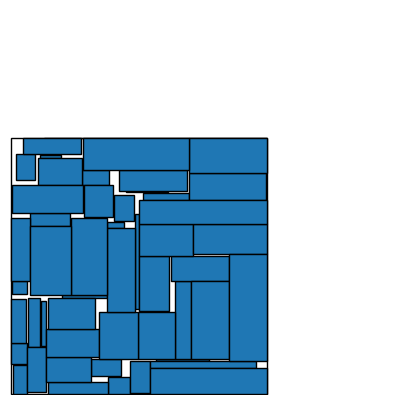

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def display_map(x_best: list[Rectangle]):
    fig = plt.figure(figsize=(5, 5))
    ax = plt.axes()

    r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
    ax.add_patch(r)

    for rect in x_best:
        r = patches.Rectangle(xy=(rect.x1, rect.y1), width=rect.width, height=rect.height, ec='#000000', fill=True)
        ax.add_patch(r)

    plt.xlim(-5, 1500)
    plt.ylim(-5, 1500)
    plt.axis('off')
    ax.set_aspect('equal')
    plt.show()

display_map(x_best)